# Anomaly Detection Using Isolation Forest
The goal in this notebook is to train an Isolation Forest (IF) algorithm to flag anomalous data within the [kaggle bank transaction data set](https://www.kaggle.com/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection), and compare the flagged points to those flagged as anomalous by an Auto Encoder (AE) within a [previous study](https://github.com/Jcardenas34/fraud_detection/blob/main/notebooks/fraud_detection_autoencoder.ipynb). I will then investigate the degree to which these data points could be flagged as anomalous by both the IF and the AE by chance, using a Poisson null hypothesis test. In a hypothetical business context, if both anomaly detection methods converge on a set of points they flag as anomalous with very little statistical probability to have been grouped by chance (p-value < $0.05$), they then become candidates for  review by humans to confirm a fraud event. 

### Key Findings
In this study, I found the IF and AE algorithms to have anomaly detection rates of about 1% and 3% respectively, in a data set of 2512 transactions. 
Of these transactions flagged as anomalous, **the IF and AE had 25 transactions in common**. Given independent training of the algorithms, one expects about 1 transaction to be in the overlap region of the two. Modeling anomalous transaction coincidence rates as a Poisson distribution with mean .72, the observed p-value is $8.75\times10^{-30}$, well below the threshold for statistical significance. This degree of significance points to an underlying structure within this set of data points, rather than coincidentally flagging the same data points as anomalous.


### Larger Role in the Anomaly Detection Pipeline
Training an Isolation Forest (IF) algorithm for comparison with the results of the Auto Encoder (AE) network establishes a multi-tiered data validation pipeline where data points flagged by both models can be triaged for investigation where a labeled fraud data set will be created. At this early stage, one cannot confirm whether the transactions in fact are fraudulent, they are only high-confidence statistical anomalies that require further study. Once fraudulent transactions are confirmed, they can then be labeled and used to train supervised models, further improving our fraud detection capabilities.

### Goal metrics: 
- What is the % overlap of anomalous events from IF and AE.
- To what degree can this overlap be attributed to random chance.

In [1]:
import sys
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib_venn import venn2
from matplotlib.colors import LogNorm
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix

# Custom implementation class for sklean Isolation forest
from fraud_detection.models import IsolationForestModel

In [2]:
# Verify working path
!pwd

/mnt/c/Users/Carde/Desktop/git_projects/fraud_detection/notebooks


In [3]:
# Load the data set, un-normalized since IF makes cuts on the variable distribution, no normalization needed.
data_path = "../dataset/credit_card_fraud.h5"
df = pd.read_hdf(data_path, key='fraud_dataset')
df.head()

,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionDate_hour,TransactionWeekNumber,DaysSinceLastPurchase
0,1,0,70,0,81,1,5112.21,2,16,15,572.652083
1,1,0,68,0,141,1,13758.91,3,16,26,495.642361
2,1,2,19,3,56,1,1122.35,1,18,28,482.577083
3,1,2,26,3,25,1,8569.06,3,16,18,548.650694
4,0,2,26,3,198,1,7429.40,0,17,42,384.593750


In [4]:
def fit_model_and_show_anomaly_rate(IF_model, dataset) -> list:
    '''
    Shows the anomaly rate of a given set of IF scores.
    Score threshold is set at 0, below 0 is flagged as anomalous.
    Above 0 is ordinary transactions.
    Args:
        IF_model: A list of IF scores produced by decision_function()
        dataset: A pandas dataset that will be evaluated for anomalous transactions
    return:
        results: A numpy array of evauation scores for the dataset
        score_samples: A numpy array of evaluation scores using 'score_samples' method
    '''
    # Fit the model
    fitted_model = IF_model.fit(dataset)
    results = fitted_model.decision_function(dataset)
    # Gather Scores
    score_samples = fitted_model.score_samples(dataset)
    # Determine anomaly rate
    n_anomalous_points = sum(results<0)
    anomaly_rate = sum(results<0)/len(results)
    non_anomaly_rate = sum(results>0)/len(results)

    # Quality assurance the proportions sum to 1
    assert anomaly_rate+ non_anomaly_rate == 1

    # Showing characteristics of scores to user
    print(f"Total Events: {len(results)}")
    print(f"N Anomalous points: {n_anomalous_points}")
    print(f"Anomaly Rate:     {anomaly_rate*100:.2}%")
    print(f"Non Anomaly Rate: {non_anomaly_rate*100:.2f}%")
    print(f"Score Min: {min(results):.3f}, Score Max: {max(results):.3f}")
    
    return results, score_samples
    

In [5]:
# Control model, setting contamination level  
control_model = IsolationForestModel(expected_fraud_rate=0.01).get_if_model()
IF_scores, score_samples = fit_model_and_show_anomaly_rate(control_model, df)

Total Events: 2512
N Anomalous points: 26
Anomaly Rate:     1.0%
Non Anomaly Rate: 98.96%
Score Min: -0.053, Score Max: 0.174


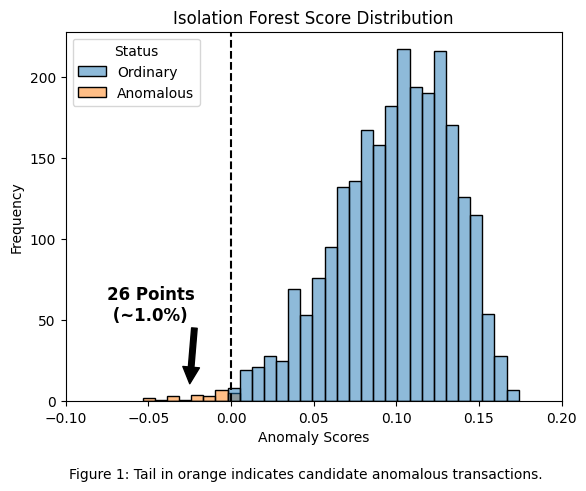

In [6]:
# Plotting the scores from decision_function()
IF_results_as_series = pd.DataFrame(IF_scores, columns=["IF_scores"])
# Adding more descriptive score labels
IF_results_as_series["Status"] = (IF_results_as_series["IF_scores"] < 0).map({
    True: "Anomalous", 
    False: "Ordinary"
})

sns.histplot(data=IF_results_as_series, x="IF_scores", hue="Status")
plt.axvline(0, color="black", linestyle="--")
plt.title("Isolation Forest Score Distribution")
plt.ylabel("Frequency")
plt.xlabel("Anomaly Scores")
plt.xlim(-.1,.2)
anomalous_cm = -0.025
plt.annotate(f'26 Points\n (~{1.0:.1f}%)', xy=(anomalous_cm, 10), xytext=(anomalous_cm-0.05, 50),
             arrowprops=dict(facecolor='black', shrink=0.02), fontsize=12, color='black', fontweight='bold')
plt.figtext(0.5, -0.05, "Figure 1: Tail in orange indicates candidate anomalous transactions.", ha="center", fontsize=10)
plt.savefig('../plots/isolation_forest_anomalous_score_distribution.png', bbox_inches='tight')

# Anomaly Score Analysis : Isolation Forest
As observed by the histograms above, we can see that ~1% of the total data set was flagged as anomalous by the Isolation Forest algorithm. We will then gather these anomalous scores and compare them to those identified as anomalous by the Auto Encoder algorithm, and quantify the overlap.

# Anomaly Score Analysis: Auto Encoder
Results from the [previous study](https://github.com/Jcardenas34/fraud_detection/blob/main/notebooks/fraud_detection_autoencoder.ipynb) regarding Auto encoder is loaded here for comparison with the IF model.

In [8]:
# Load data from VAE and AE for model comparison, do they score the same events as anomalous?
model_scores = pd.read_csv("../dataset/identified_fraud_autoencoder.csv")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [9]:
model_scores.columns

Index(['Unnamed: 0', 'TransactionType', 'Channel', 'CustomerAge',
       'CustomerOccupation', 'TransactionDuration', 'LoginAttempts',
       'AccountBalance', 'PreviousTransactionDate', 'TransactionDate_hour',
       'TransactionWeekNumber', 'DaysSinceLastPurchase', 'MSE_AE_zscores',
       'MSE_AE', 'MSE_AE_Fraud'],
      dtype='object')

In [10]:
# Evaluate the model with the scores from the stored data set, to ensure they are THE SAME data points
dataset = model_scores[['TransactionType', 'Channel', 'CustomerAge',
       'CustomerOccupation', 'TransactionDuration', 'LoginAttempts',
       'AccountBalance', 'PreviousTransactionDate', 'TransactionDate_hour',
       'TransactionWeekNumber', 'DaysSinceLastPurchase']]

In [11]:
# Evaluating the loaded data set with the trained IF algorithm
IF_scores_loaded_data, _ = fit_model_and_show_anomaly_rate(control_model, dataset)

Total Events: 2512
N Anomalous points: 26
Anomaly Rate:     1.0%
Non Anomaly Rate: 98.96%
Score Min: -0.053, Score Max: 0.174


In [12]:
# Append the Isolation Forest scores to the loaded data set
# Create and indicator of fraud or no fraud for the IF scores
model_scores["IF_scores"] = IF_scores_loaded_data
model_scores["IF_scores_fraud"] = model_scores["IF_scores"] < 0

In [13]:
model_scores.head()

,Unnamed: 0,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionDate_hour,TransactionWeekNumber,DaysSinceLastPurchase,MSE_AE_zscores,MSE_AE,MSE_AE_Fraud,IF_scores,IF_scores_fraud
0,0,1,0,70,0,81,1,5112.21,2,16,15,572.652083,-0.434677,0.744353,False,0.132657,False
1,1,1,0,68,0,141,1,13758.91,3,16,26,495.642361,0.015130,1.008898,False,0.107279,False
2,2,1,2,19,3,56,1,1122.35,1,18,28,482.577083,0.195357,1.114895,False,0.092712,False
3,3,1,2,26,3,25,1,8569.06,3,16,18,548.650694,-0.347123,0.795847,False,0.092841,False
4,4,0,2,26,3,198,1,7429.40,0,17,42,384.593750,0.514001,1.302300,False,0.036414,False


In [14]:
# Create a column indicating fraud agreement between models
model_scores["AE_IF_agreement"] = (model_scores["MSE_AE_Fraud"]==True) & (model_scores["IF_scores_fraud"]==True)

In [15]:
model_scores.head()

,Unnamed: 0,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionDate_hour,TransactionWeekNumber,DaysSinceLastPurchase,MSE_AE_zscores,MSE_AE,MSE_AE_Fraud,IF_scores,IF_scores_fraud,AE_IF_agreement
0,0,1,0,70,0,81,1,5112.21,2,16,15,572.652083,-0.434677,0.744353,False,0.132657,False,False
1,1,1,0,68,0,141,1,13758.91,3,16,26,495.642361,0.015130,1.008898,False,0.107279,False,False
2,2,1,2,19,3,56,1,1122.35,1,18,28,482.577083,0.195357,1.114895,False,0.092712,False,False
3,3,1,2,26,3,25,1,8569.06,3,16,18,548.650694,-0.347123,0.795847,False,0.092841,False,False
4,4,0,2,26,3,198,1,7429.40,0,17,42,384.593750,0.514001,1.302300,False,0.036414,False,False


In [16]:
# Looks like there are 25 transactions flagged as anomalous by both models
n_agree_fraud = model_scores[model_scores["AE_IF_agreement"]]["AE_IF_agreement"].count()
n_dataset = model_scores["AE_IF_agreement"].count()
print(f"Models agree: {n_agree_fraud} transactions are fraud")
print(f"Total number of transactions in dataset: {n_dataset}")

Models agree: 25 transactions are fraud
Total number of transactions in dataset: 2512


In [17]:
# There are 70 flagged as anomalous by the AE
n_AE_fraud = model_scores[model_scores["MSE_AE_Fraud"]==True]["MSE_AE_Fraud"].count()
print(f"AE Model: {n_AE_fraud} transactions as fraud")
print(f"AE Model Anomaly flagging rate: {n_AE_fraud*100/n_dataset:.2f}% transactions as anomalous")
print(f"Percent in agreement with IF: {n_agree_fraud*100/n_AE_fraud:.2f}%")

AE Model: 70 transactions as fraud
AE Model Anomaly flagging rate: 2.79% transactions as anomalous
Percent in agreement with IF: 35.71%


In [18]:
# There are 26 flagged as anomalous by the IF
n_IF_fraud = model_scores[model_scores["IF_scores_fraud"]==True]["IF_scores_fraud"].count()
print(f"IF Model: {n_IF_fraud} transactions as fraud")
print(f"IF Model Anomaly flagging rate: {n_IF_fraud*100/n_dataset:.2f}% transactions as anomalous")
print(f"Percent in agreement with AE: {n_agree_fraud*100/n_IF_fraud:.2f}%")

IF Model: 26 transactions as fraud
IF Model Anomaly flagging rate: 1.04% transactions as anomalous
Percent in agreement with AE: 96.15%


# Analysis Conclusions
Based on the results shown above, we can see that 96% of the fraudulent events flagged by the Isolation Forest (IF) Algorithm were also flagged by the Auto Encoder (AE). These points represent high confidence statistical anomalies, candidates for review by a data annotator and worthy of high priority alerts, but not yet confirmed fraudulent transactions. By contrast only ~36% of the events flagged as fraud by the AE are in agreement with the IF, meaning that AE as a much more liberal threshold on what it considers fraudulent activity. 

As a reminder, these fraud determinations for the AE were made using +-2 sigma Z-Scores. Versus an IF contamination rate of 0.01

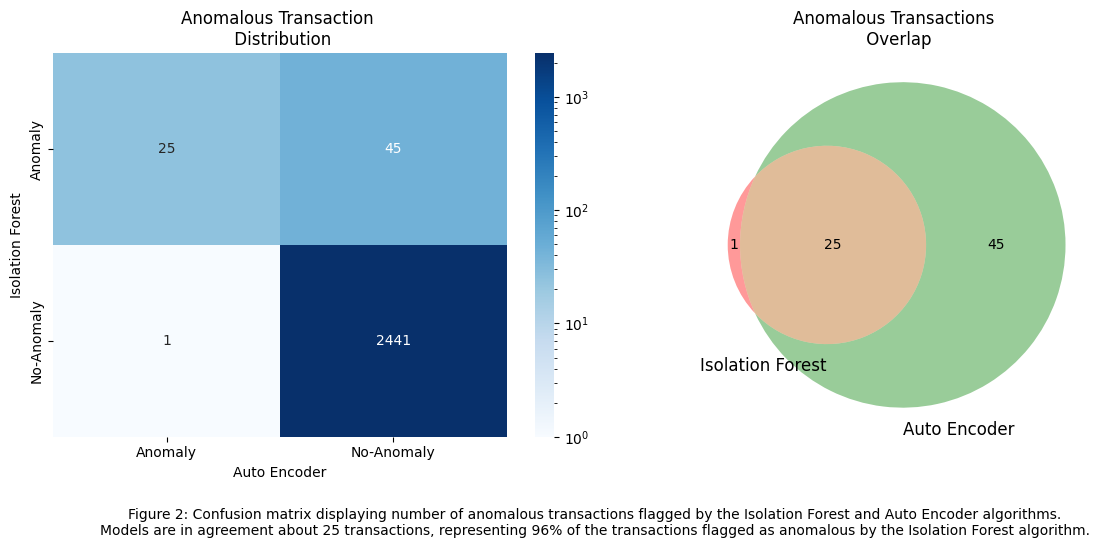

In [19]:
# Creating a confusion matrix and venn diagram to display overlap in anomalous transactions between models
IF_vs_AE_conf_matrix = confusion_matrix(model_scores["MSE_AE_Fraud"], model_scores["IF_scores_fraud"])
# Create the heat map
fig, axes = plt.subplots(1,2, figsize=(12,5))
hm = sns.heatmap(ax=axes[0], data=IF_vs_AE_conf_matrix, annot=True, fmt='g', cmap='Blues', norm=LogNorm(),
            xticklabels=['No-Anomaly', 'Anomaly'], 
            yticklabels=['No-Anomaly', 'Anomaly'])

# To show True positive overlap at top right
hm.invert_yaxis()
hm.invert_xaxis()

axes[0].set_title("Anomalous Transaction \n Distribution")
axes[0].set_xlabel('Auto Encoder')
axes[0].set_ylabel('Isolation Forest')
plt.figtext(0.5, -0.08, 
            "Figure 2: Confusion matrix displaying number of anomalous transactions flagged by the Isolation Forest and Auto Encoder algorithms.\n" 
            "Models are in agreement about 25 transactions, representing 96% of the transactions flagged as anomalous by the Isolation Forest algorithm.",
           ha="center")
axes[1].set_title("Anomalous Transactions \n Overlap")
venn2(subsets = (n_IF_fraud-n_agree_fraud, n_AE_fraud-n_agree_fraud, n_agree_fraud), set_labels = ('Isolation Forest', 'Auto Encoder'))

plt.tight_layout()
plt.savefig('../plots/isolation_forest_autoencoder_anomalous_transactions_agreement.png', bbox_inches='tight')
plt.show()



# Probability of Overlap by Chance
At this point it makes sense to ask weather the points that are agreed upon by both the IF and the AE could have occurred by chance. What is the likelihood that there is a 96% overlap in the Isolation Forest anomalous transactions? Given that the IF and AE algorithms were trained independently (No output from one is being used in the other) they are independent events. 

So with anomaly flagging rates for the IF and AE at 1.04% and 2.79% respectively, the expected rate at which any given transaction would appear within BOTH subsets flagged as anomalous is $.0104\times.0279 = 0.00029016$ or $0.029016\%$, leading to $0.00029016\times2512=.72$ transactions on average. We observe 25 events within the set.

Because we are modeling random occurrences we can model the them as a Poisson distribution with mean at .72 and calculate the probability of observing 25 or greater. Leading to a p-value $p=8.75\times10^{-30}$ . There is then an overwhelming probability that there is an underlying structure, and the events were not grouped by chance. Makes sense given the synthetically generated [kaggle bank transaction data set](https://www.kaggle.com/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection).

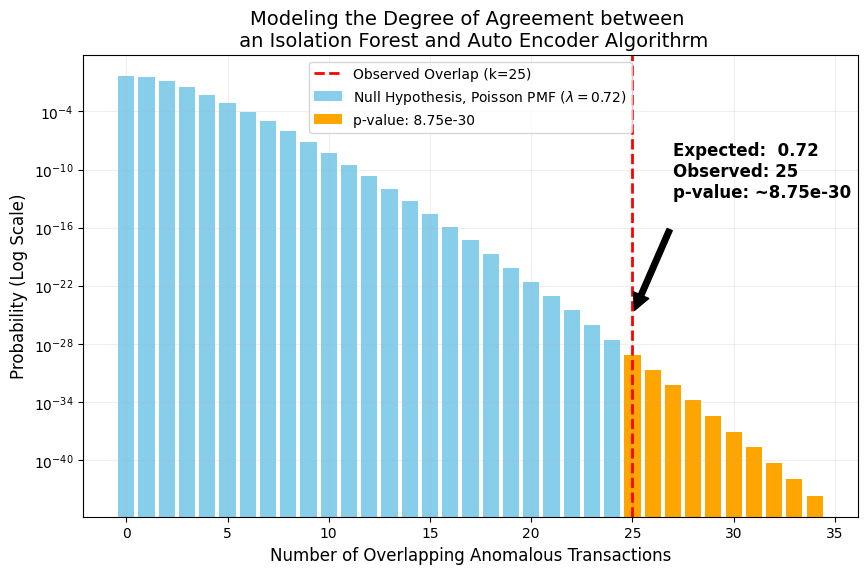

In [24]:
from scipy.stats import poisson
from scipy.interpolate import interp1d

# observed parameters from analysis
mu = 0.72
observed_k = 25

# Precise P-value using the Survival Function (1 - CDF)
p_value = poisson.sf(observed_k - 1, mu)

plt.figure(figsize=(10, 6))

# Create a color label array
colors = ["skyblue" if x < observed_k else "orange" for x in x_int ]

# Distinguishing between chance and anomaly regions 
plt.bar(x_int[x_int<observed_k], pmf_values[x_int<observed_k], color="skyblue", label=f'Null Hypothesis, Poisson PMF ($\lambda={mu}$)')
plt.bar(x_int[x_int>=observed_k], pmf_values[x_int>=observed_k], color="orange", label=f'p-value: {p_value:.2e}')

# Vertical line at 25, the number of observed overlap events
plt.axvline(observed_k, color='red', linestyle='--', linewidth=2, label=f'Observed Overlap (k={observed_k})')

# Formatting axes
plt.yscale('log')
plt.title(f'Modeling the Degree of Agreement between \n an Isolation Forest and Auto Encoder Algorithrm', fontsize=14)
plt.xlabel('Number of Overlapping Anomalous Transactions', fontsize=12)
plt.ylabel('Probability (Log Scale)', fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

# Annotation for the p-value
plt.annotate(f'Expected:  0.72 \nObserved: 25\np-value: ~{p_value:.2e} \n ', xy=(observed_k, 1e-25), xytext=(observed_k+2, 1e-15),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12, color='black', fontweight='bold')

plt.savefig('../plots/poisson_distribution_fraud_overlap.png', bbox_inches='tight')

# Future work
- Investigate the 25 transactions labeled as anomalous by both the IF and AE algorithms, what makes them different
- Further probe anomalous transactions by evaluating them via another ML model
- Use anomalous events to generate a synthetic data set of anomalous events and simulate model drift

# Exporting the data
Lets also export this dataset, so that we can make comparisons as to which transactions were flagged as fraud across methods

In [ ]:
model_scores.to_csv("./identified_fraud_autoencoder_and_IF.csv")